# 2x2 LRS ndlar-flow Tutorial: 2026 ND-Prototypes Analysis Workshop

### Most of the steps outlined in this tutorial can be investigated in greater detail through James Mead's 2026 LRS tutorial repository, linked here: [github.com/jvmead/lrs_tutorials](https://github.com/jvmead/lrs_tutorials).


### Step 1: Load the relevant packages

In [ ]:
%%capture
!pip install jupyter matplotlib h5py numpy legacy-cgi scienceplots
!cd ../.. && git clone https://github.com/DUNE/h5flow && pip install -e ./h5flow
!cd .. && pip install -e .

In [2]:
import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

from h5flow.data import dereference
from lut import LUT

### Step 2: Open a file

In [3]:
fname = '/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.flow/FLOW/0000000/MiniRun6.5_1E19_RHC.flow.0000000.FLOW.hdf5'
f = h5py.File(fname)

A helpful function for reading said file: 

In [4]:
def h5_tree(val, pre='',skip_ref=False):
    items = len(val)
    for key, val in val.items():
        items -= 1
        if items == 0:
            # the last item
            if type(val) == h5py._hl.group.Group:
                print(pre + '└── ' + key)
                if key=="ref" and skip_ref:
                    continue
                h5_tree(val, pre+'    ')
            else:
                print(pre + '└── ' + key + ' (%d)' % len(val))
        else:
            if type(val) == h5py._hl.group.Group:
                print(pre + '├── ' + key)
                h5_tree(val, pre+'│   ')
            else:
                print(pre + '├── ' + key + ' (%d)' % len(val))

h5_tree(f)

├── charge
│   ├── calib_final_hits
│   │   ├── data (79593)
│   │   └── ref
│   │       └── charge
│   │           ├── calib_prompt_hits
│   │           │   └── ref_region (79593)
│   │           ├── events
│   │           │   └── ref_region (79593)
│   │           └── raw_events
│   │               └── ref_region (79593)
│   ├── calib_prompt_hits
│   │   ├── data (102586)
│   │   └── ref
│   │       ├── charge
│   │       │   ├── calib_final_hits
│   │       │   │   ├── ref (79593)
│   │       │   │   └── ref_region (102586)
│   │       │   ├── events
│   │       │   │   └── ref_region (102586)
│   │       │   ├── packets
│   │       │   │   ├── ref (102586)
│   │       │   │   └── ref_region (102586)
│   │       │   └── raw_events
│   │       │       └── ref_region (102586)
│   │       └── mc_truth
│   │           └── calib_prompt_hit_backtrack
│   │               ├── ref (102586)
│   │               └── ref_region (102586)
│   ├── events
│   │   ├── data (187)
│   │   └── ref
│   │

A more basic file structure check:

In [5]:
my_func = lambda name,dset : print(name) if isinstance(dset, h5py.Dataset) \
    else None
f.visititems(my_func)

charge/calib_final_hits/data
charge/calib_final_hits/ref/charge/calib_prompt_hits/ref_region
charge/calib_final_hits/ref/charge/events/ref_region
charge/calib_final_hits/ref/charge/raw_events/ref_region
charge/calib_prompt_hits/data
charge/calib_prompt_hits/ref/charge/calib_final_hits/ref
charge/calib_prompt_hits/ref/charge/calib_final_hits/ref_region
charge/calib_prompt_hits/ref/charge/events/ref_region
charge/calib_prompt_hits/ref/charge/packets/ref
charge/calib_prompt_hits/ref/charge/packets/ref_region
charge/calib_prompt_hits/ref/charge/raw_events/ref_region
charge/calib_prompt_hits/ref/mc_truth/calib_prompt_hit_backtrack/ref
charge/calib_prompt_hits/ref/mc_truth/calib_prompt_hit_backtrack/ref_region
charge/events/data
charge/events/ref/charge/calib_final_hits/ref
charge/events/ref/charge/calib_final_hits/ref_region
charge/events/ref/charge/calib_prompt_hits/ref
charge/events/ref/charge/calib_prompt_hits/ref_region
charge/events/ref/charge/ext_trigs/ref
charge/events/ref/charge/ext

### Step 3: Understand the various light branches

In [6]:
# print structure of light
print("Available LRS Branches:")
print(f['light'].keys())

print("\nWaveforms are located in f['light/wvfm/data']['samples]:")
print("['samples'] is the only dataset in f['light/wvfm/data'].dtype.names:", f['light/wvfm/data'].dtype.names)
print("\nIt stores data by [triggered event, ADC board, SiPM channel, waveform tick]:", f['light/wvfm/data']['samples'].shape)

Available LRS Branches:
<KeysViewHDF5 ['cwvfm', 'events', 'flash', 'sipm_hits', 'stpc_wvfm', 'sum_hits', 'sum_tpc_hits', 'swvfm', 't_ns', 'wvfm']>

Waveforms are located in f['light/wvfm/data']['samples]:
['samples'] is the only dataset in f['light/wvfm/data'].dtype.names: ('samples',)

It stores data by [triggered event, ADC board, SiPM channel, waveform tick]: (187, 8, 64, 1000)


Depending on what dataset you're using (Run 1 or 3 beam data, Run 2 AmBe data, Run 2 Radon data, etc.), the waveforms may be different lengths. 

**Beam data waveforms are 1000 ticks long, where each tick spans 16 ns.**

| Data Run | Ticks per Waveform |
|---|---|
| `Run 1` NuMI Beam Data | 1000 |
| `Run 2 AmBe` | 550 to 2000 (subrun-dependent) |
| `Run 2 Radon` | 600 |
| `Run 2 Gamma Sources` | 400 |
| `Run 2 DTG` | 500 (DTG On), 2000 (DTG Off) |
| `Run 3 NuMI Beam Data` | 1000 |
| `Simulation` | 1000 |

Run 2 overview linked: [here](https://docs.google.com/spreadsheets/d/1NR_aXH5iqT0PCavD9b9W1xMj7ZQGwBNc0Faybm7sH20/edit?usp=sharing)

In [7]:
light_wvfms = f['light/wvfm/data/']['samples']

# figure out the number of ticks in a waveform:
SAMPLES = light_wvfms.shape[-1]
print('Number of ticks in a waveform: ', SAMPLES)

# plot an example waveform from the data
example_event = 0
example_adc = 0
example_channel = 63

# get the waveforms
light_wvfm = light_wvfms[example_event, example_adc, example_channel, :]

# another example from data
light_wvfm2 = light_wvfms[0, 3, 46, :]
light_wvfm3 = light_wvfms[0, 1, 4, :]

Number of ticks in a waveform:  1000


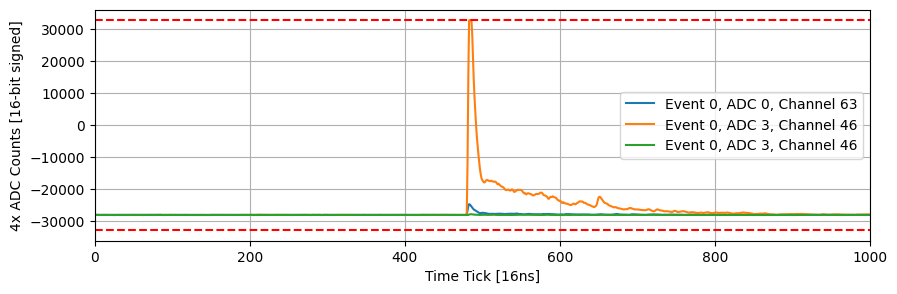

In [8]:
plt.figure(figsize=(10,3))
plt.plot(light_wvfm, label='Event {}, ADC {}, Channel {}'.format(example_event, example_adc, example_channel))
plt.plot(light_wvfm2, label='Event 0, ADC 3, Channel 46')
plt.plot(light_wvfm3, label='Event 0, ADC 3, Channel 46')
plt.xlim(0, len(light_wvfm))
#overlay line at 32767 and -32768
plt.axhline(y=32767, color='r', linestyle='--')
plt.axhline(y=-32768, color='r', linestyle='--')
plt.xlabel('Time Tick [16ns]')
plt.ylabel('4x ADC Counts [16-bit signed]')
plt.legend()
plt.grid()
plt.show()

### Light Events: The branch for charge-light matching

| Dataset Name | Definition |
|---|---|
| `id` | Counting light events in file from 0 |
| `event` | Counting light events in file from 0 (**NOT CHARGE EVENT ID**) |
| `sn` | Serial numbers of the ADC boards recorded in file |
| `utime_ms` | NTP ms timestamp of light trigger (**syned to CRS/any other NTP timestamp**) |
| `tai_ns` | White Rabbit ns timestamp, not synced to NTP |
| `wvfm_valid` | Mask for inactive channels (channels not connected to SiPMs) |

In [9]:
# print structure of events
print("Structure of light/data/events:")
print(f['light/events/data'].dtype.names)

Structure of light/data/events:
('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid')


### Step 4: Charge-Light Event Matching

### When Referencing: 

There are two types of reference branch: 
1. branch_A/**ref**/branch_B/**ref_region**
2. branch_A/**ref**/branch_B/**ref**

Typically, you use both to reference (unless you use the h5flow dereference function)  
Suppose you want to find the calib_final_hits associated with a given event ID.    
charge/event/data and charge/calib_final_hits/data are different sizes! 

How do we start with charge/events/data and end with an appropriate index cut for calib_final_hits?

In [10]:
ev_id = 0
event = f['charge/events/data'][ev_id]

First, we use the f['branch_A/**ref**/branch_B/**ref_region**'] branch:

The f['branch_A/**ref**/branch_B/**ref_region**'] is an array of arrays like [[0 2][3 7]...]   

It has as many entries as branch_A, such that its shape is: [len(branch_A), 2] with keys ['start', 'stop'].

['start'] is the first index in branch_B asociated with the ev_id for an event in branch_A.    
['stop'] is the last index in branch_B assiciated with the ev_id in branch_A.

branch_B is the branch you want to perform a cut on.

In [11]:
href_start = f['charge/events/ref/charge/calib_final_hits/ref_region'][ev_id,'start']
href_stop = f['charge/events/ref/charge/calib_final_hits/ref_region'][ev_id,'stop']

Here we apply the cut to  branch_A/ref/branch_B/ref:  
This outputs an array with [ev_id, branch_B index] for every branch_B indice linked to ev_id (the event id from branch_A).

In [12]:
hit_ref = f['charge/events/ref/charge/calib_final_hits/ref'][href_start:href_stop]

Cuts need to be a sequential array, so we make sure there's only one ev_id, and the indices are ordered.   
Then, we apply the cut to branch_B:

In [13]:
hit_ref = np.sort(hit_ref[hit_ref[:,0] == ev_id, 1])
hits_trk = f['charge/calib_final_hits/data'][hit_ref]
print(f['charge/calib_final_hits/data'].dtype.names)

('id', 'x', 'y', 'z', 't_drift', 'ts_pps', 'io_group', 'io_channel', 'chip_id', 'channel_id', 'Q_raw', 'Q', 'E', 'is_disabled')


Formatted as a function:

In [14]:
def one_to_many(event_id, h5file, one_entry_field, many_entry_field):
    print(one_entry_field+'/data')
    one_index = h5file[one_entry_field+'/data'][event_id]
    print(one_entry_field+'/ref/'+many_entry_field+'/ref_region')
    href_start = h5file[one_entry_field+'/ref/'+many_entry_field+'/ref_region'][event_id, 'start']
    href_stop = h5file[one_entry_field+'/ref/'+many_entry_field+'/ref_region'][event_id, 'stop']
    h_ref = h5file[one_entry_field+'/ref/'+many_entry_field+'/ref'][href_start:href_stop]
    h_ref = np.sort(h_ref[h_ref[:,0] == event_id, 1])
    print(many_entry_field+'/data')
    h_trk = h5file[many_entry_field+'/data'][h_ref]
    
    return h_trk

### Using this funciton to match between charge and light events:

In [17]:
# Note: this is simulation, so charge / light matching is 1:1

light_evts = one_to_many(0, f, 'charge/events', 'light/events')
print('Light/events keys:',light_evts.dtype.names)
light_wvfms = one_to_many(light_evts['id'][0], f, 'light/events', 'light/wvfm')
print('Light/wvfms key:', light_wvfms.dtype.names)
print('samples shape:', np.shape(light_wvfms['samples']))

charge/events/data
charge/events/ref/light/events/ref_region
light/events/data
Light/events keys: ('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid')
light/events/data
light/events/ref/light/wvfm/ref_region
light/wvfm/data
Light/wvfms key: ('samples',)
samples shape: (1, 8, 64, 1000)


### A Note on Geometry:

* Every ADC board (Warm-side Analog to Digital Converter) has 64 available channels   
* Per ADC board, the 2x2 LRS uses 48 of the 64 channels to record light waveforms from SiPMs (Sillicon PhotoMultipliers).   
* We can use f['light/events/data']['wvfm_valid'] to select for this. 

The "inactive" channels are consistent for every ADC board, so we can also mask that way.

In [18]:
## Method 1: ##

valid_wvfm = light_evts['wvfm_valid']
print('Valid Waveform Shape:',np.shape(valid_wvfm))
wvfms_0 = light_wvfms['samples'][0,0,:][valid_wvfm[0,0,:]==1]
print('Method 1, New Light Waveform Shape:',np.shape(wvfms_0))

## Method 2: ##

sipm_channels = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])

wvfms_1 = light_wvfms['samples'][0, 0, sipm_channels, :]
print('Method 2, New Light Waveform Shape:',np.shape(wvfms_1))

Valid Waveform Shape: (1, 8, 64)
Method 1, New Light Waveform Shape: (48, 1000)
Method 2, New Light Waveform Shape: (48, 1000)


## Plotting Charge and Light Together:

### First: more light geometry

h5_tree(f["geometry_info"]) saves positions of the various light traps and channels:

In [19]:
h5_tree(f["geometry_info"])

├── anode_drift_coordinate
│   └── data (257)
├── det_bounds
│   └── data (129)
├── det_id
│   └── data (481)
├── det_rel_pos
│   └── data (129)
├── det_type
│   └── data (129)
├── disabled_channels
│   └── data (30392)
├── disabled_chips
│   └── data (176)
├── drift_dir
│   └── data (257)
├── pixel_coordinates_2D
│   └── data (1638401)
├── sipm_abs_pos
│   └── data (481)
├── sipm_rel_pos
│   └── data (481)
└── tile_id
    └── data (4097)


### Geometry Branch:

| Branch Name | Definition |
|---|---|
| `det_bounds` | This defines the shape of the two types of light traps coupled to SiPMs, also called the light detectors |
| `det_id` | We use indices to refer to the positions of the 16 light traps in a given TPC |
| `det_rel_pos` | This is the position of each of the 16 light trap centers relative to the center of the TPC |
| `det_type` | 0 is an ACL trap type, and 1 is an LCM trap type |
| `sipm_abs_pos` | Absolute positions of SiPMs in the 2x2 |
| `sipm_rel_pos` | Relative positions of SiPMs in the 2x2 |

In [20]:
sipm_abs_pos = LUT.from_array(f["geometry_info/sipm_abs_pos"].attrs["meta"],f["geometry_info/sipm_abs_pos/data"])
# sipm_abs_pos[(adc,chan)] = [x,y,z] in cm

sipm_rel_pos = LUT.from_array(f["geometry_info/sipm_rel_pos"].attrs["meta"],f["geometry_info/sipm_rel_pos/data"])
# sipm_rel_pos[(adc,chan)] = [tpc, side, vertical position]
# side: 0 = -z (upstream beam direction), 1 = +z (downstream beam direction)
# vertical position: index starting from bottom (0-23)

det_bounds = LUT.from_array(f["geometry_info/det_bounds"].attrs["meta"],f["geometry_info/det_bounds/data"])
# det_bounds[(tpc,det)] = [[x_min, y_min, z_min],[x_max, y_max, z_max]] in cm 

det_rel_pos = LUT.from_array(f["geometry_info/det_rel_pos"].attrs["meta"],f["geometry_info/det_rel_pos/data"])
# det_rel_pos[(tpc,det)] = [tpc, side, vertical position]
# side: 0 = -z (upstream beam direction), 1 = +z (downstream beam direction)
# vertical position: index starting from bottom (0-15)

det_id = LUT.from_array(f["geometry_info/det_id"].attrs["meta"],f["geometry_info/det_id/data"])
# det_id[(adc,chan)] = det_id
# 0-16 for each TPC

### Using Billy's Q + L Plotting Tool:

Billy's written this fantastic tool, charge_light_starter:

In [22]:
# import his function
import charge_light_starter.cl_display as cl

h5, tbl = cl.open_flow(fname)

opened MiniRun6.5_1E19_RHC.flow.0000000.FLOW.hdf5: 187 charge events, 187 light events (1000-tick window), 187 charge-light pairs


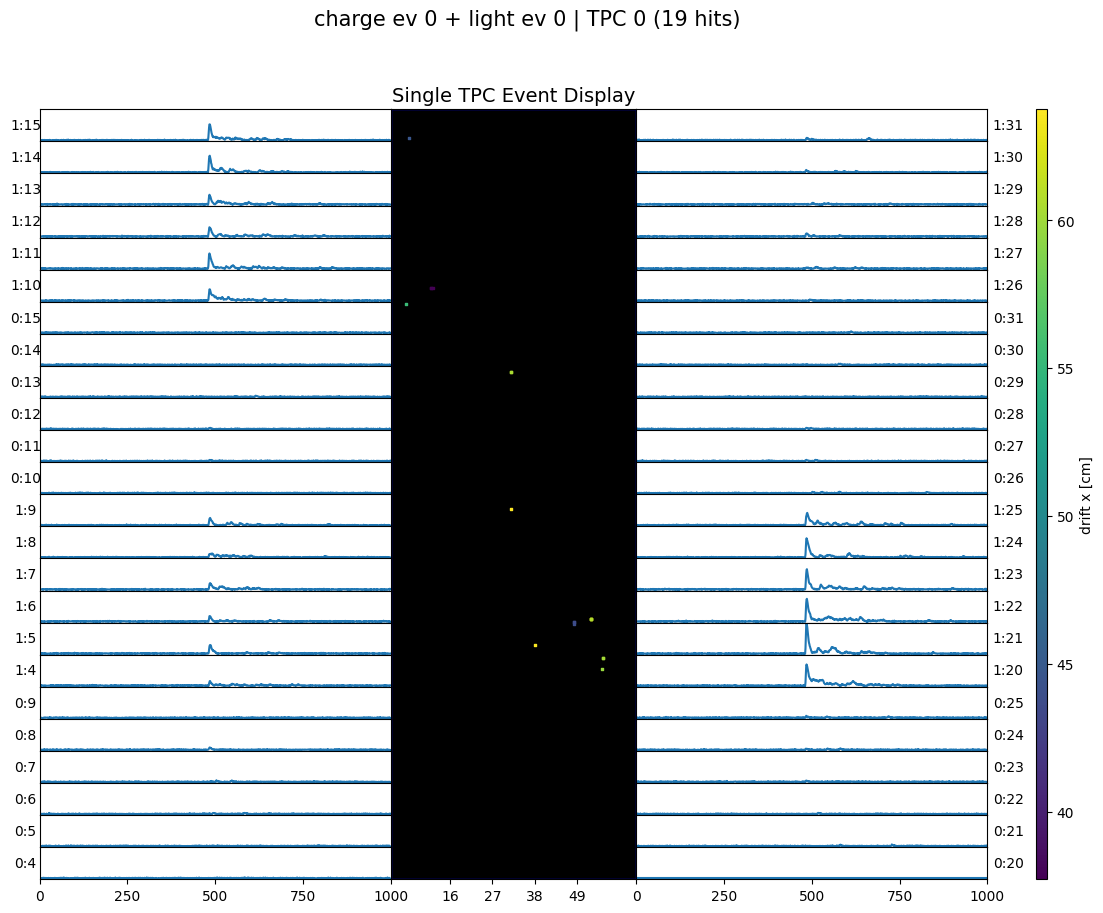

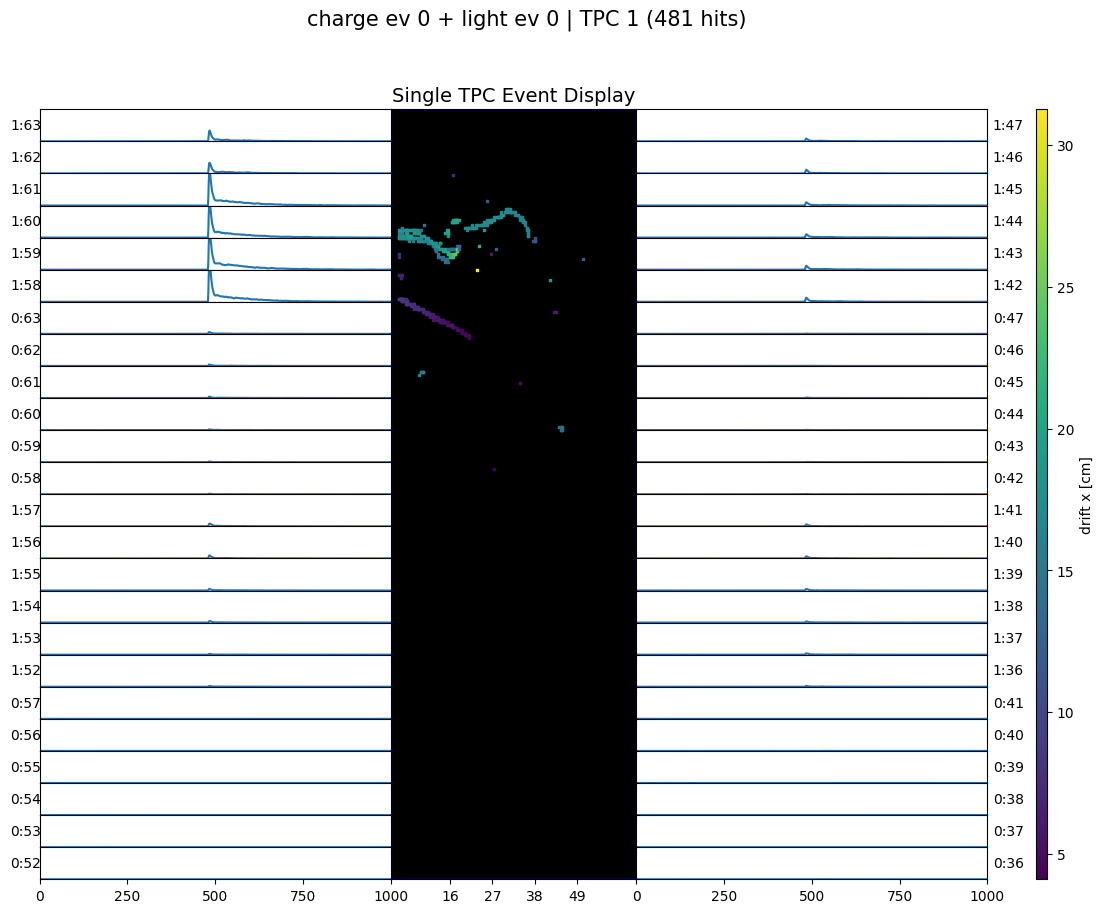

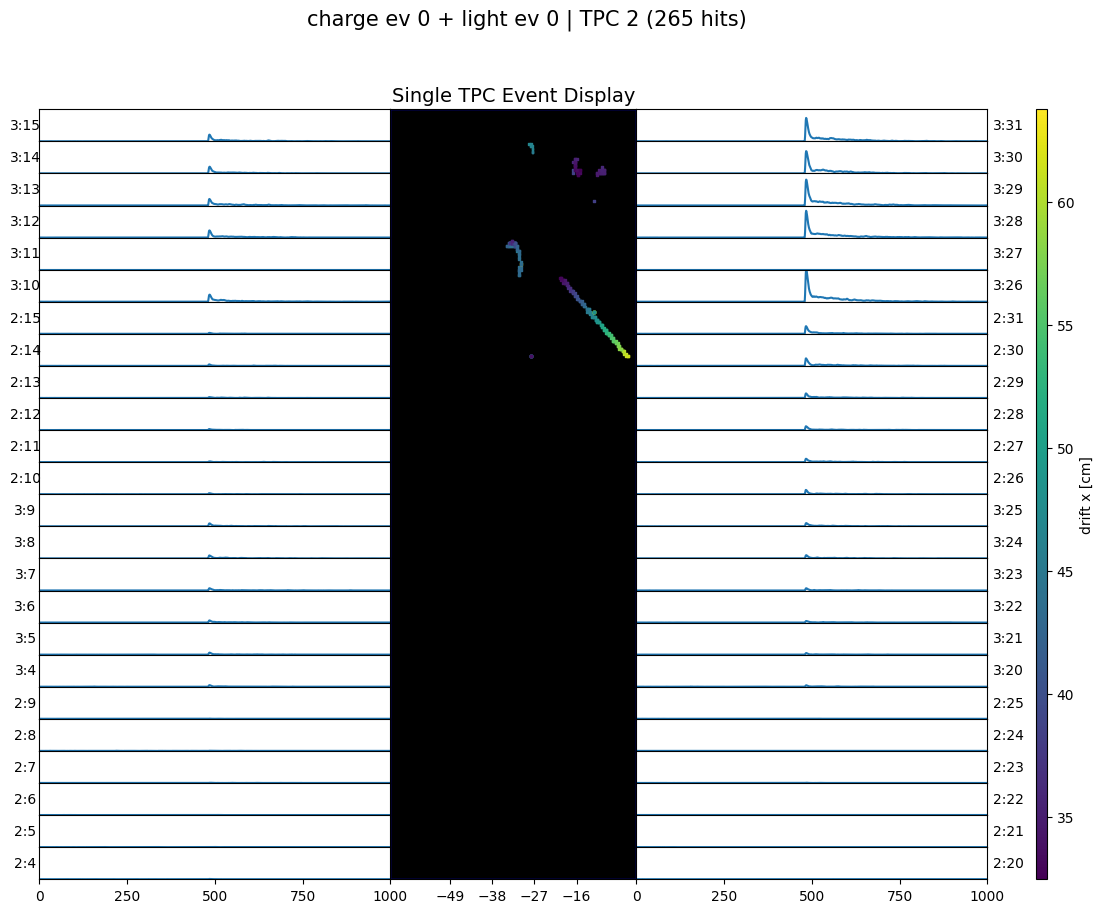

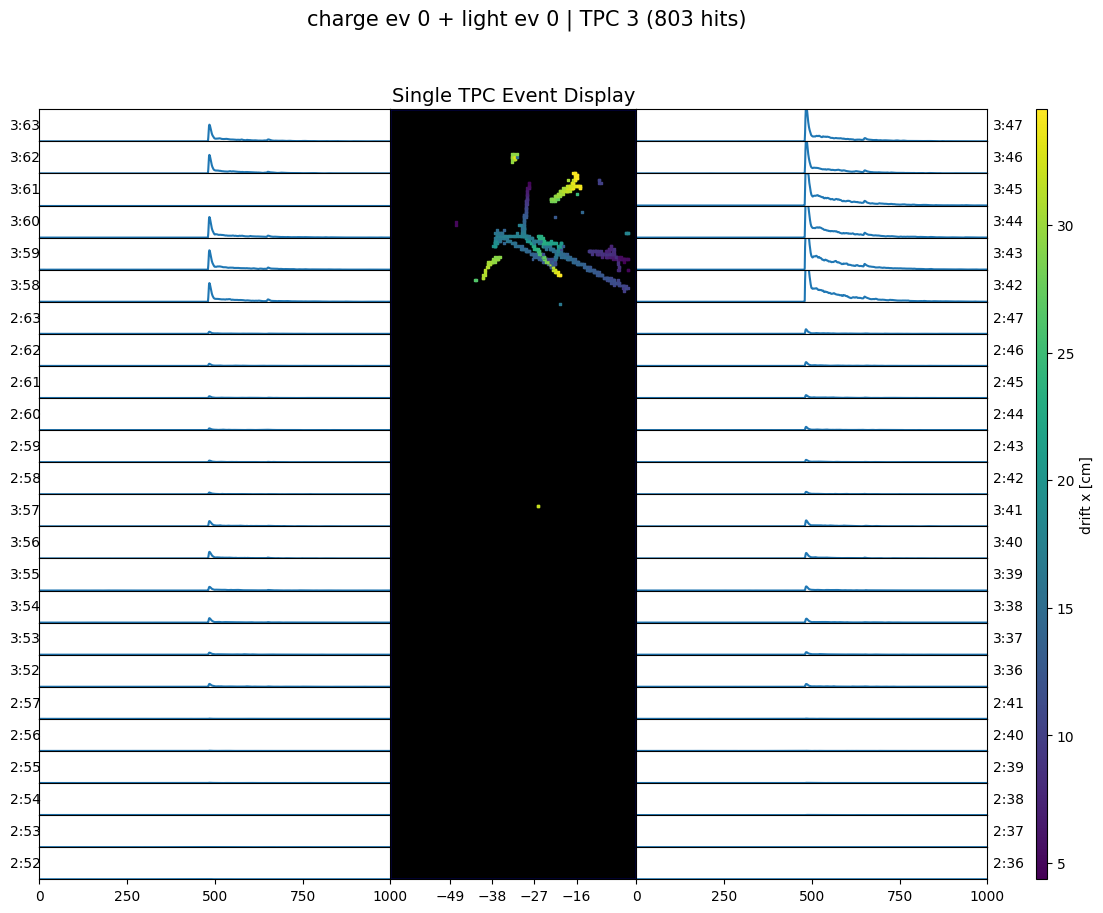

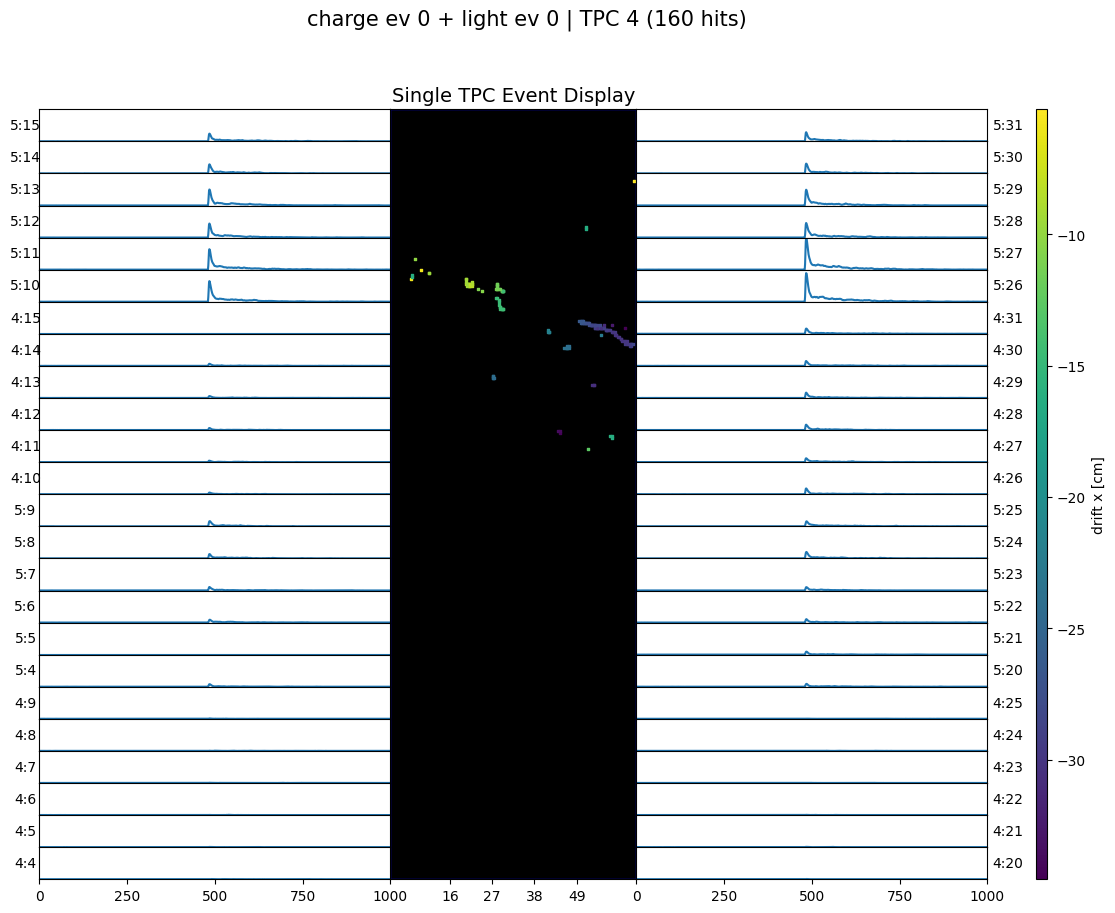

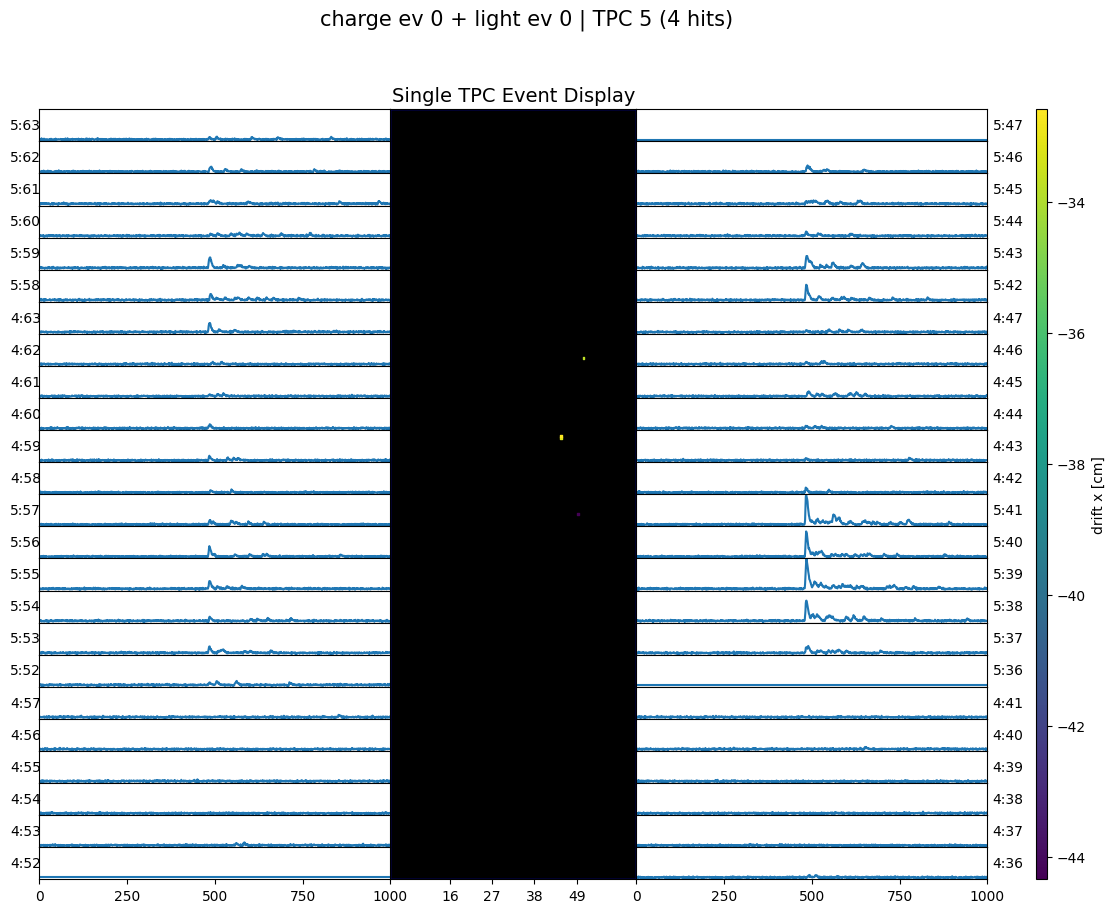

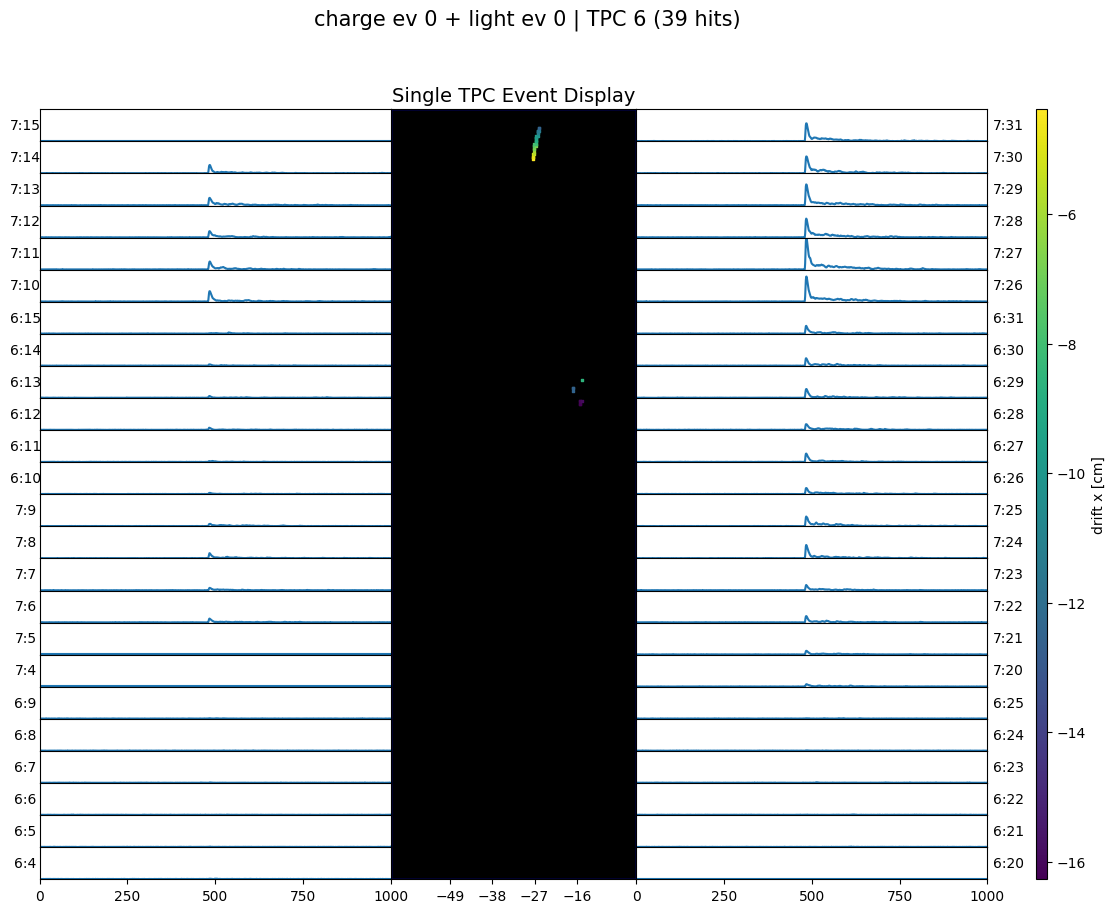

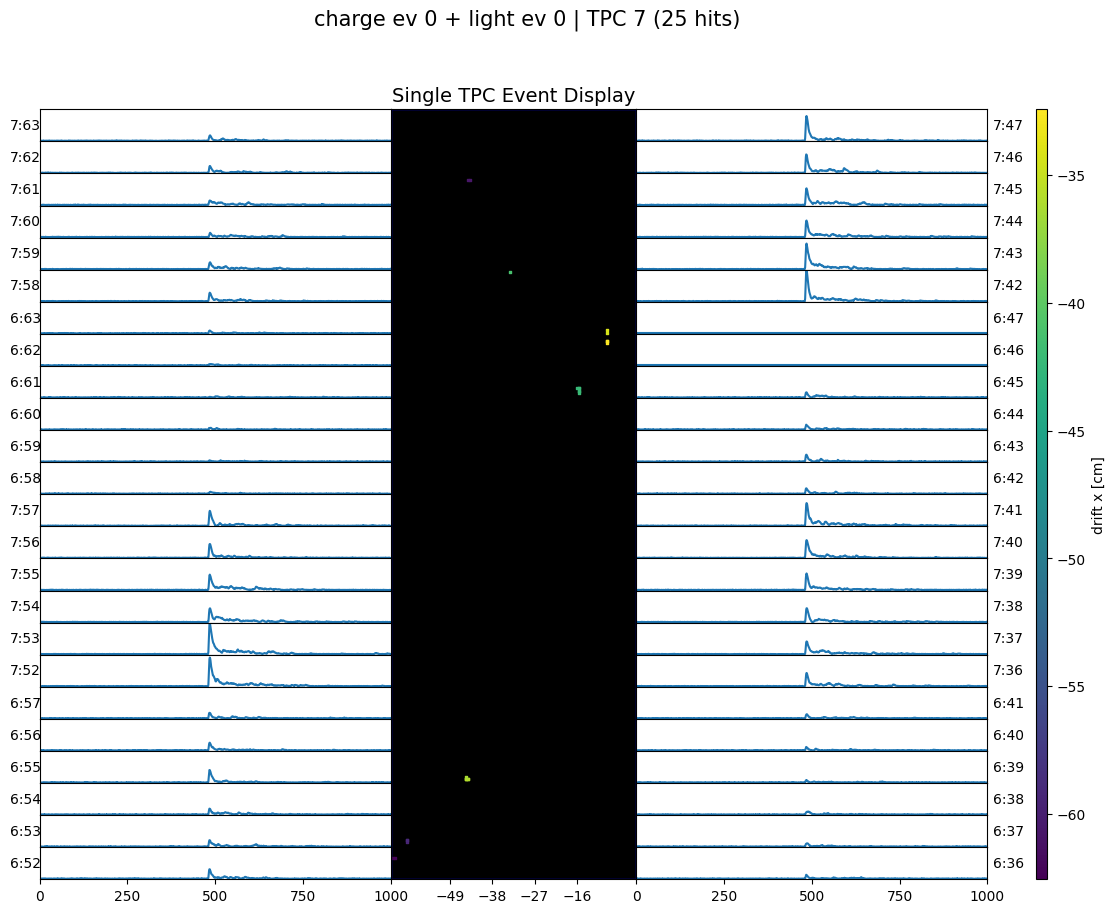

In [23]:
# We know the event IDs for the charge event and light event we want (0 and 0, since this is simulation)

charge_ev = 0      # <-- fill in
light_ev  = 0       # <-- fill in

cl.show_pair(h5, tbl, charge_ev, light_ev)

### Upstream of Raw Waveforms: Additional LRS Datasets

| Branch Name | Definition |
|---|---|
| `sipm_hits` | Hits identified in individual SiPM channel waveforms: **sensitive to noise** |
| `sum_hits` | Hits identified in sum waveform of SiPMs coupled to a common light trap: **preferred hit branch** |
| `sum_tpc_hits` | Hits identified in sum waveform of all (ACL/LCM) SiPMs in a TPC: **can wash out detail** |
| `flashes` | Light object across all TPCs in a 160 ns window |


In [18]:
# print structure of sipm hits
print("\nStructure of light/data/sipm_hits:")
print(f['light/sipm_hits/data'].dtype.names)

# print structure of sum_hits
print("\nStructure of light/data/sum_hits:")
print(f['light/sum_hits/data'].dtype.names)

# print structure of sum_tpc_hits
print("\nStructure of light/data/sum_tpc_hits:")
print(f['light/sum_tpc_hits/data'].dtype.names)

# print structure of flashes
print("\nStructure of light/data/flash:")
print(f['light/flash/data'].dtype.names)

Structure of light/data/events:
('id', 'event', 'sn', 'utime_ms', 'tai_ns', 'wvfm_valid')

Structure of light/data/sipm_hits:
('id', 'adc', 'chan', 'pos', 'sample_idx', 'ns', 'busy_ns', 'samples', 'sum', 'max', 'sum_spline', 'max_spline', 'ns_spline', 'rising_spline', 'rising_err_spline', 'fwhm_spline')

Structure of light/data/sum_hits:
('id', 'tpc', 'det', 'boundary', 'sample_idx', 'ns', 'busy_ns', 'samples', 'sum', 'max', 'sum_spline', 'max_spline', 'ns_spline', 'rising_spline', 'rising_err_spline', 'fwhm_spline')

Structure of light/data/sum_tpc_hits:
('id', 'tpc', 'trap_type', 'sample_idx', 'ns', 'busy_ns', 'samples', 'sum', 'max', 'sum_spline', 'max_spline', 'ns_spline', 'rising_spline', 'rising_err_spline', 'fwhm_spline', 'integral', 'fprompt')

Structure of light/data/flash:
('id', 'tpc', 'n_sum_hits', 'sample_range', 'hit_time_range', 'rising_spline_range', 'tot_sum', 'tot_max', 'tot_sum_spline', 'tot_max_spline', 'deconv_sum', 'deconv_max')


### Hit structure

**Note: many "spline" values are intended to be used with deconvolved light waveforms, which are not produced in the current flow pipeline.**

| Name              | Type             | Description                                                                                             |
| ----------------- | ---------------- | ------------------------------------------------------------------------------------------------------- |
| id                | u4              | unique identifier within branch                                                                                       |
| adc / tpc         | u1              | TPC or ADC location of hit index                                                                                        |
| chan / det / trap_type      | u1              | SiPM channel, light trap index, or indicator of ACL / LCM sum within a TPC                                                                              |
| pos / boundary    | f4(3) / f4(3,2) | (x,y,z) center of sipm / ((xmin,xmax), (ymin,ymax), (zmin,zmax)) boundary of detector sensitive surface |
| sample_idx        | u2              | sample (tick) index of peak within waveform                                                                    |
| ns                | f8              | White Rabbit timestamp of waveform [ns]                                                                           |
| busy_ns           | f8              | timestamp of peak relative to trigger [ns]                                                              |
| samples           | f4(2\*near+1,)  | sample value around peak (±near_samples)                                                                |
| sum               | f4              | sum of sample values (out to ±near_samples)                                                             |
| max               | f4              | peak value (post-calibration)                                                                                             |
| sum_spline        | f4              | integral of spline around peak (out to ±near_samples)                                                   |
| max_spline        | f4              | maximum of spline around peak                                                                           |
| ns_spline         | f4              | offset from center sample for maximum of spline [ns]                                                    |
| rising_spline     | f4              | projection of spline to rising edge zero-crossing (offset from center sample) [ns]                      |
| rising_err_spline | f4              | an estimate of the error on the rising edge zero-                                                       |
| fwhm_spline       | f4              | spline FWHM [ns]     |
| integral          | f4              | integral of 3200 ns window following peak [p.e.]   |
| fprompt           | f4              | ratio of integral of 200 ns window following peak [p.e.] and the 3200 ns integral

light/events/data
light/events/ref/light/sipm_hits/ref_region
light/sipm_hits/data
('id', 'adc', 'chan', 'pos', 'sample_idx', 'ns', 'busy_ns', 'samples', 'sum', 'max', 'sum_spline', 'max_spline', 'ns_spline', 'rising_spline', 'rising_err_spline', 'fwhm_spline')
(189, 3, 42, [3.06, 33.95, -2.01], 482, 200000099.0, 6112.0, [0.04998064, 49.78681, 939.8384, 1389.0012, 1389.0012, 1389.0012, 1389.0012, 1389.0012, 1389.0012], 9323.683, 1389.0012, 8554.637, 1414.7048, -9.788236, 0.0, 0.0, 0.0944625)


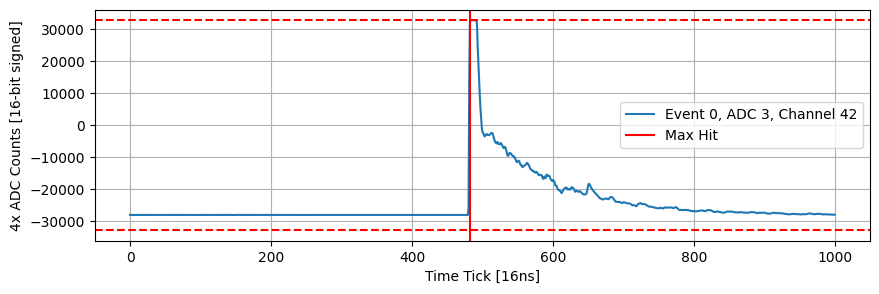

In [40]:
light_sum_hit_0 = one_to_many(light_evts['id'][0], f, 'light/events', 'light/sipm_hits')
print(light_sum_hit_0.dtype.names)
max_sipm_hit_idx = np.argmax(light_sum_hit_0['max'])
print(light_sum_hit_0[max_sipm_hit_idx])

plt.figure(figsize=(10,3))
plt.plot(light_wvfms['samples'][light_evts['id'][0], light_sum_hit_0[max_sipm_hit_idx]['adc'], light_sum_hit_0[max_sipm_hit_idx]['chan'], :], label='Event {}, ADC {}, Channel {}'.format(light_evts['id'][0], light_sum_hit_0[max_sipm_hit_idx]['adc'], light_sum_hit_0[max_sipm_hit_idx]['chan']))
#overlay line at 32767 and -32768
plt.axvline(light_sum_hit_0[max_sipm_hit_idx]['sample_idx'], color='tab:orange', label='Max Hit', linestyle=':', linewidth=3)
plt.scatter(light_sum_hit_0[max_sipm_hit_idx]['sample_idx'], light_sum_hit_0[max_sipm_hit_idx]['max'], color='orangered', s=50)
plt.axhline(y=32767, color='r', linestyle='--')
plt.axhline(y=-32768, color='r', linestyle='--')
plt.xlabel('Time Tick [16ns]')
plt.ylabel('4x ADC Counts [16-bit signed]')
plt.legend()
plt.grid()
plt.show()

### If anybody's feeling revved up about light:
* James Mead has scripts for LRS processing and validation here: [github.com/jvmead/light_file_processing](https://github.com/jvmead/light_file_processing)